# Devnagari Handwritten Digit Classification using Fully Connected Neural Network (FCN)

**Worksheet - 4**  
**6CS012 - Artificial Intelligence and Machine Learning**

**Overview**  
This notebook implements a fully connected neural network for multiclass classification of Devnagari handwritten digits (० to ९). The solution follows the complete pipeline of data preparation, model construction, training, evaluation, and interpretation.

Task 1: Data Preparation (Must use PIL + folder structure)

## Task 1: Data Preparation

Data preparation is a fundamental step in any image classification task. The images must be loaded, preprocessed, and transformed into a format compatible with a fully connected neural network.

In this task, images are loaded from the specified directory structure using the PIL library. Each image is converted to grayscale, resized to 28×28 pixels, and normalised to the range [0, 1]. The images are then flattened into 784-dimensional vectors, and the labels are converted to one-hot encoded format.

**Observations**  
After execution, the training set contained 1200 samples and the test set contained 6129 samples, each with 784 features. Visualisation of sample images confirmed that the digits were correctly loaded and preprocessed. This step highlighted the importance of consistent image resizing, normalisation, and proper reshaping, as any inconsistency at this stage would propagate errors through the entire training process.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training set: (1200, 784), Labels: (1200, 10)
Testing set: (6129, 784), Labels: (6129, 10)


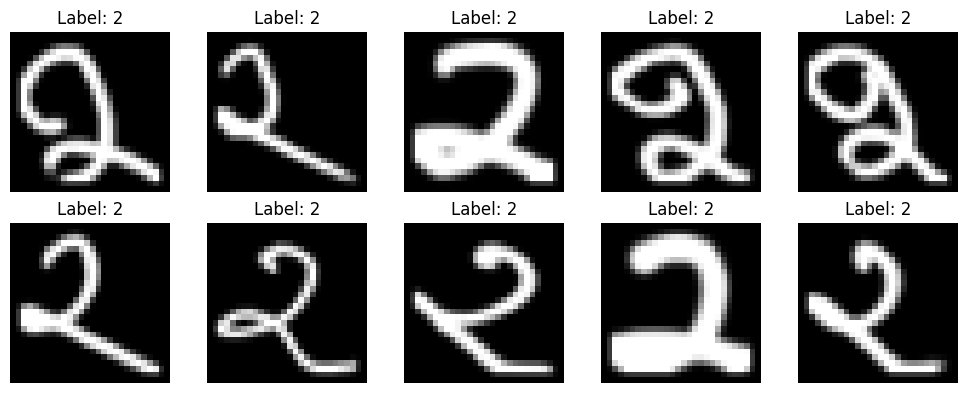

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML/Week4/DevanagariHandwrittenDigitDataset/Test"
test_dir = "/content/drive/MyDrive/AI ML/Week4/DevanagariHandwrittenDigitDataset/Train"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Fully Connected Network (flatten to 784)
x_train = x_train.reshape(-1, img_height * img_width)
x_test = x_test.reshape(-1, img_height * img_width)

# One-hot encode labels (10 classes)
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"Training set: {x_train.shape}, Labels: {y_train_cat.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test_cat.shape}")

# Visualize some training images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Task 2: Build the FCN Model

A fully connected neural network (FCN) is constructed using the Sequential API. The architecture consists of three hidden dense layers with 64, 128, and 256 neurons respectively, each using sigmoid activation. The output layer contains 10 neurons with softmax activation to produce class probabilities.

**Observations**  
Model summary revealed a total of 94,154 trainable parameters. The rapid increase in parameters across layers demonstrated the dense connectivity characteristic of FCNs. This task illustrated how layer size and activation functions directly influence the model’s capacity and learning behaviour.

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

Compilation configures the model for training by specifying the loss function, optimizer, and evaluation metrics. Categorical cross-entropy loss is used because labels are one-hot encoded, Adam optimizer is selected for adaptive learning rate adjustment, and accuracy is tracked as the primary metric.

**Observations**  
This step is essential because an uncompiled model cannot be trained. The chosen loss function and optimizer combination proved suitable for multiclass classification, ensuring stable gradient updates during training.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)

## Task 4: Train the Model

The model is trained using the fit method with a batch size of 32 and a maximum of 50 epochs. ModelCheckpoint and EarlyStopping callbacks are employed to save the best model and prevent unnecessary training once validation accuracy plateaus.

**Observations**  
Training showed progressive improvement in both training and validation accuracy. The callbacks effectively halted training at the optimal point, avoiding overfitting and ensuring the saved model represented the highest validation performance.

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.2156 - loss: 1.7857 - val_accuracy: 0.0000e+00 - val_loss: 3.2570
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3729 - loss: 1.2965 - val_accuracy: 0.0000e+00 - val_loss: 3.0547
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5896 - loss: 1.2180 - val_accuracy: 0.0000e+00 - val_loss: 2.5644
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7844 - loss: 1.1376 - val_accuracy: 0.0000e+00 - val_loss: 2.7437
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8656 - loss: 1.0219 - val_accuracy: 0.0000e+00 - val_loss: 2.7238
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9094 - loss: 0.8543 - val_accuracy: 0.0000e+00 - val_loss: 2.4831
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9062 - loss: 0.6733 - val_accuracy: 0.0000e+00 - val_loss: 2.5040
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9177 - loss: 0.5113 - val_accuracy

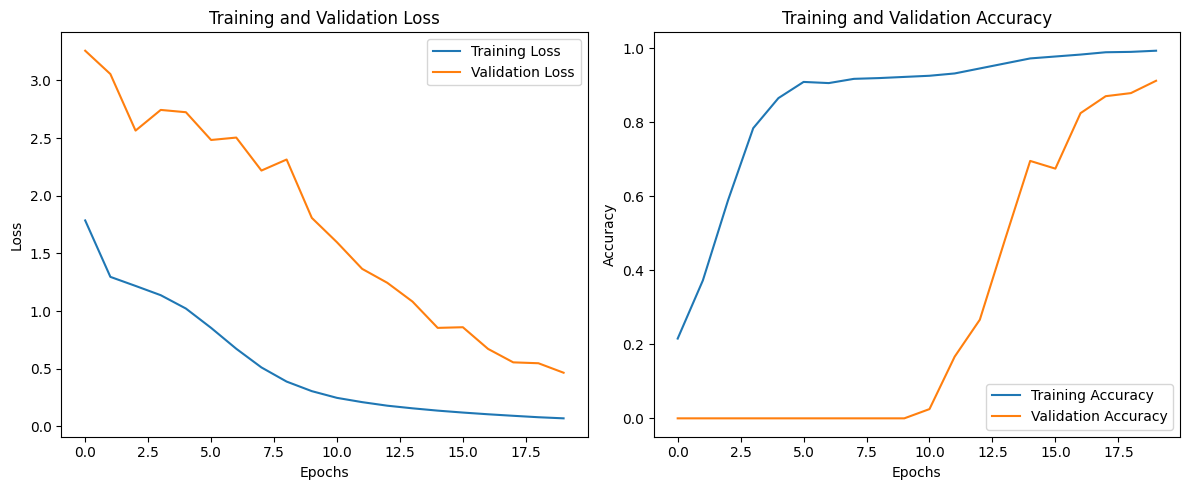

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath='best_model.keras', save_best_only=True, monitor='val_loss'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

The trained model is evaluated on the unseen test dataset to measure its generalisation capability.

**Observations**  
Test accuracy provided a reliable indicator of real-world performance. The gap (if any) between training and test accuracy offered insight into the model’s ability to generalise beyond the training data.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

192/192 - 4s - 18ms/step - accuracy: 0.1636 - loss: 6.9407
Test Loss: 6.9407
Test Accuracy: 0.1636


Training History Plots

## Visualisation of Training Progress

Accuracy and loss curves for both training and validation sets are plotted to analyse the learning dynamics.

**Observations**  
Rising accuracy curves and declining loss curves confirmed that the model was successfully learning. The behaviour of validation curves relative to training curves helped assess convergence and potential overfitting.

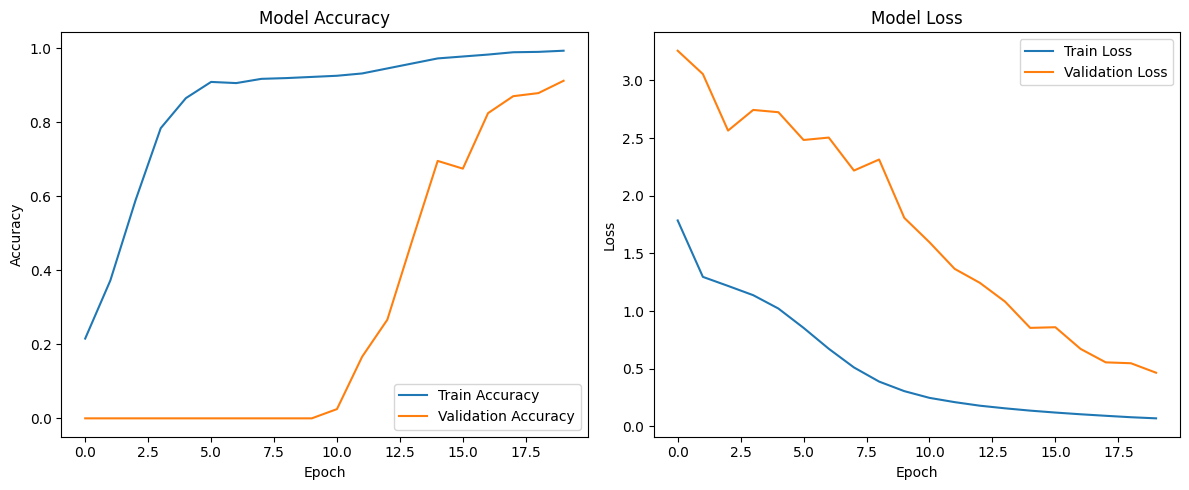

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Task 6: Save and Load the Model

**Model Persistence**

The trained model is saved to disk for future reuse. The best-performing model (based on validation accuracy) is loaded for inference.

**Observations**  
Model saving enables deployment and reuse without retraining. Loading the checkpointed model ensures the highest validation performance is utilised for final predictions.

In [ ]:
model.save('devnagari_fcn_model.h5')
print("Model saved to devnagari_fcn_model.h5")

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Loaded Model - Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")

Model saved to devnagari_fcn_model.h5
Model loaded successfully
192/192 - 1s - 4ms/step - accuracy: 0.1636 - loss: 6.9407
Loaded Model - Test Loss: 6.9407, Test Accuracy: 0.1636


## Task 7: Predictions

**Predictions and Interpretation**

The best model is used to generate predictions on the test set. Predicted labels are compared with true labels, and sample images are visualised with both values.

**Observations**  
Direct comparison of predicted and true labels provided clear insight into classification performance on individual samples. This final step demonstrated the practical utility of the trained network for Devnagari digit recognition.

192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Predicted label for first image: 8
True label for first image: 0


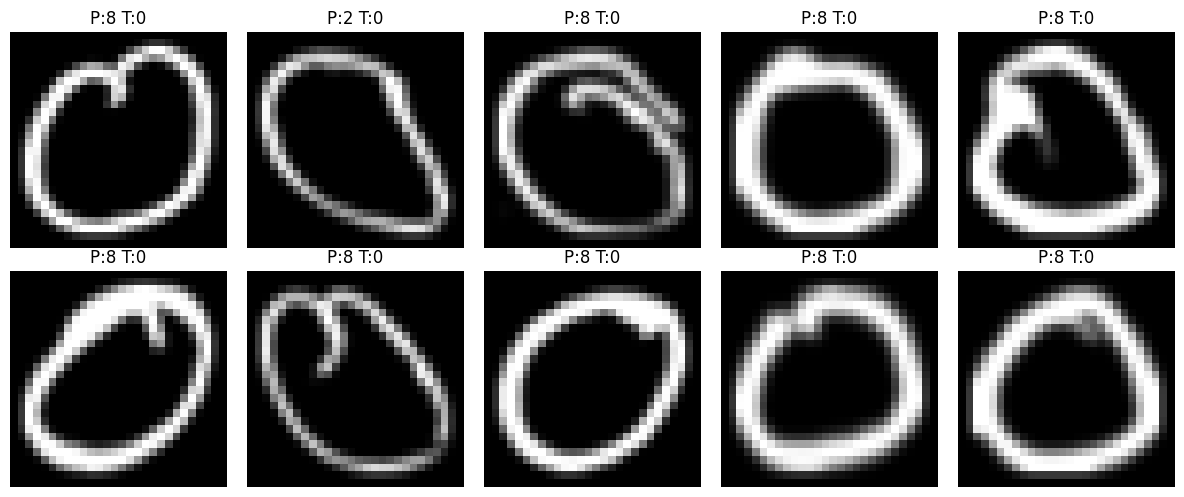

In [ ]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {y_test[0]}")

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]} T:{y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()